In [ ]:
# ============================================
# download  libraries
# ============================================


!nvidia-smi


!pip install -U ultralytics
!pip install albumentations==1.4.0


import os
import cv2
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
import random
import shutil
from datetime import datetime
import albumentations as A
from tqdm import tqdm


print(f"CUDA متاح: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

🔍 التحقق من وجود GPU...
Mon Feb 23 18:52:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------

In [ ]:
# ============================================
# اLoad Dataset GTSDB
# ============================================




!wget -O GTSDB.zip "https://sid.erda.dk/public/archives/ff17dc924eba88d5d01a807357d6614c/FullIJCNN2013.zip"


!unzip -q GTSDB.zip -d GTSDB/

data_path = 'GTSDB/FullIJCNN2013'
gt_file = f'{data_path}/gt.txt'



!ls -la GTSDB/FullIJCNN2013/ | head -10

⏳ جاري تحميل بيانات GTSDB...
--2026-02-23 18:53:14--  https://sid.erda.dk/public/archives/ff17dc924eba88d5d01a807357d6614c/FullIJCNN2013.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1661866983 (1.5G) [application/zip]
Saving to: ‘GTSDB.zip’

GTSDB.zip           100%[===================>]   1.55G  16.6MB/s    in 93s     

2026-02-23 18:54:48 (17.1 MB/s) - ‘GTSDB.zip’ saved [1661866983/1661866983]

✅ تم تحميل وفك الضغط!

📂 محتويات المجلد:
total 2869464
drwxr-xr-x 45 root root   32768 Jul  9  2013 .
drwxr-xr-x  3 root root    4096 Feb 23 18:54 ..
drwxr-xr-x  2 root root    4096 Jul  9  2013 00
-rw-r--r--  1 root root 3264016 Nov 26  2012 00000.ppm
-rw-r--r--  1 root root 3264016 Nov 26  2012 00001.ppm
-rw-r--r--  1 root root 3264016 Nov 26  2012 00002.ppm
-rw-r--r--  1 root root 3264016 Nov 26  2012 00003.ppm
-rw-r--r--  1 root root 3264016 Nov 26  

In [ ]:
# ============================================
# Display Dataset Statistics
# ============================================

def read_gtsdb_annotations(annotation_file):
    
    annotations = {}

    with open(annotation_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split(';')

            if len(parts) >= 6:
                try:
                    img_name = parts[0]
                    xmin = int(parts[1])
                    ymin = int(parts[2])
                    xmax = int(parts[3])
                    ymax = int(parts[4])
                    class_id = int(parts[5])

                    width = xmax - xmin
                    height = ymax - ymin

                    if img_name not in annotations:
                        annotations[img_name] = []

                    annotations[img_name].append({
                        'bbox': [xmin, ymin, width, height],
                        'class_id': class_id
                    })
                except:
                    continue

    return annotations

# annotations = gt_file
annotations = read_gtsdb_annotations(gt_file)

print(f"Number of images: {len(annotations)}")


total_signs = sum(len(v) for v in annotations.values())
print(f"🚦  Totla Signs: {total_signs}")


class_counts = {}
for img_anns in annotations.values():
    for ann in img_anns:
        class_id = ann['class_id']
        class_counts[class_id] = class_counts.get(class_id, 0) + 1

print(f" Num of Calsses  {len(class_counts)}")

📸 عدد الصور: 741
🚦 إجمالي الإشارات: 1213
📊 عدد الفئات المختلفة: 43


In [ ]:
# ============================================
#  Convert to YOLO format 
# ============================================

def convert_to_yolo_format(x, y, width, height, img_width, img_height):
   
    x_center = (x + width/2) / img_width
    y_center = (y + height/2) / img_height
    w_norm = width / img_width
    h_norm = height / img_height


    x_center = max(0, min(1, x_center))
    y_center = max(0, min(1, y_center))
    w_norm = max(0, min(1, w_norm))
    h_norm = max(0, min(1, h_norm))

    return x_center, y_center, w_norm, h_norm


dataset_path = 'GTSDB_YOLO'
for split in ['train', 'val', 'test']:
    os.makedirs(f'{dataset_path}/images/{split}', exist_ok=True)
    os.makedirs(f'{dataset_path}/labels/{split}', exist_ok=True)

print(" تم إنشاء هيكل المجلدات")


image_names = list(annotations.keys())
random.shuffle(image_names)

train_split = int(0.7 * len(image_names))
val_split = int(0.85 * len(image_names))

train_images = image_names[:train_split]
val_images = image_names[train_split:val_split]
test_images = image_names[val_split:]

print(f"\n📊 تقسيم البيانات:")
print(f"   تدريب: {len(train_images)} صورة")
print(f"   تحقق:  {len(val_images)} صورة")
print(f"   اختبار: {len(test_images)} صورة")

def convert_dataset(img_list, split_name):
  
    converted = 0

    for img_name in tqdm(img_list, desc=f"تحويل {split_name}"):
        img_path = f'{data_path}/{img_name}'
        img = cv2.imread(img_path)

        if img is None:
            continue

        h, w = img.shape[:2]

        
        dst_img = f'{dataset_path}/images/{split_name}/{img_name.replace(".ppm", ".jpg")}'
        cv2.imwrite(dst_img, img)


        label_file = f'{dataset_path}/labels/{split_name}/{img_name.replace(".ppm", ".txt")}'

        with open(label_file, 'w') as f:
            for ann in annotations[img_name]:
                x, y, bw, bh = ann['bbox']
                class_id = ann['class_id']
                xc, yc, wn, hn = convert_to_yolo_format(x, y, bw, bh, w, h)
                f.write(f"{class_id} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}\n")

        converted += 1

    return converted


print("\n⏳ جاري تحويل البيانات...")
train_conv = convert_dataset(train_images, 'train')
val_conv = convert_dataset(val_images, 'val')
test_conv = convert_dataset(test_images, 'test')

print(f"\n✅ تم تحويل:")
print(f"   تدريب: {train_conv} صورة")
print(f"   تحقق: {val_conv} صورة")
print(f"   اختبار: {test_conv} صورة")

✅ تم إنشاء هيكل المجلدات

📊 تقسيم البيانات:
   تدريب: 518 صورة
   تحقق:  111 صورة
   اختبار: 112 صورة

⏳ جاري تحويل البيانات...


تحويل test: 100%|██████████| 112/112 [00:00<00:00, 123.18it/s]


✅ تم تحويل:
   تدريب: 518 صورة
   تحقق: 111 صورة
   اختبار: 112 صورة


In [ ]:
# ============================================
#  create data.yaml
# ============================================

data_config = {
    'path': f'/content/{dataset_path}',
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': len(class_counts),
    'names': [f'class_{i}' for i in range(len(class_counts))]
}

with open(f'{dataset_path}/data.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("✅ تم إنشاء ملف data.yaml")
print(yaml.dump(data_config, default_flow_style=False))

✅ تم إنشاء ملف data.yaml
names:
- class_0
- class_1
- class_2
- class_3
- class_4
- class_5
- class_6
- class_7
- class_8
- class_9
- class_10
- class_11
- class_12
- class_13
- class_14
- class_15
- class_16
- class_17
- class_18
- class_19
- class_20
- class_21
- class_22
- class_23
- class_24
- class_25
- class_26
- class_27
- class_28
- class_29
- class_30
- class_31
- class_32
- class_33
- class_34
- class_35
- class_36
- class_37
- class_38
- class_39
- class_40
- class_41
- class_42
nc: 43
path: /content/GTSDB_YOLO
test: images/test
train: images/train
val: images/val



✅ البيانات محولة بشكل صحيح


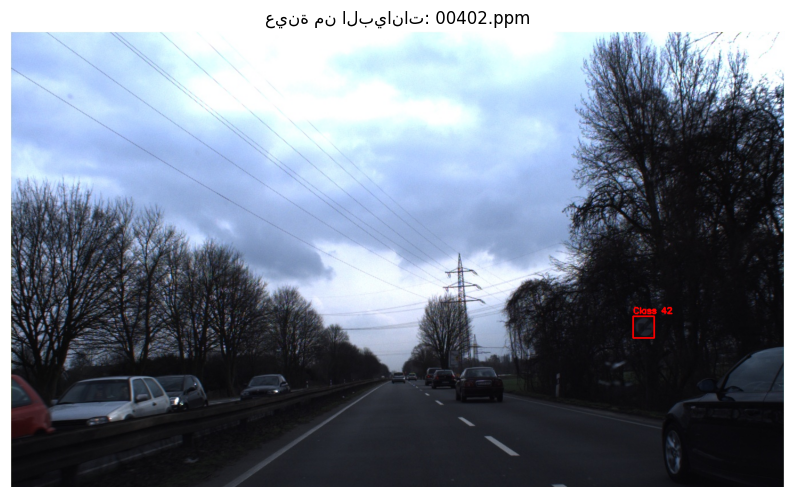

In [ ]:
# ============================================
#  Verify Converted Data
# ============================================

def verify_data():
   
    test_img = f'{dataset_path}/images/train/{train_images[0].replace(".ppm", ".jpg")}'
    test_label = f'{dataset_path}/labels/train/{train_images[0].replace(".ppm", ".txt")}'

    if os.path.exists(test_img) and os.path.exists(test_label):
        print("✅ البيانات محولة بشكل صحيح")

      
        img = cv2.imread(test_img)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        with open(test_label, 'r') as f:
            for line in f:
                class_id, xc, yc, wn, hn = map(float, line.split())
                x = int((xc - wn/2) * w)
                y = int((yc - hn/2) * h)
                bw = int(wn * w)
                bh = int(hn * h)
                cv2.rectangle(img, (x, y), (x+bw, y+bh), (255, 0, 0), 2)
                cv2.putText(img, f'Class {int(class_id)}', (x, y-5),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

        plt.figure(figsize=(10, 10))
        plt.imshow(img)
        plt.title(f'عينة من البيانات: {train_images[0]}')
        plt.axis('off')
        plt.show()
    else:
        print("❌ مشكلة في تحويل البيانات")

verify_data()

In [ ]:
# ============================================
# Train YOLO with Data Augmentation on T4 GPU
# ============================================

from ultralytics import YOLO
import torch

print("="*60)
print("🤖 بدء تدريب YOLO مع Data Augmentation على T4 GPU")
print("="*60)


print(f"\n🔍 معلومات GPU:")
print(f"   CUDA متاح: {torch.cuda.is_available()}")
print(f"   اسم GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"   الذاكرة: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB" if torch.cuda.is_available() else "")


model = YOLO('yolov8m.pt')

print(f"\n📊 معلومات التدريب:")
print(f"   • النموذج: YOLOv8m")
print(f"   • بيانات التدريب: {train_conv} صورة")
print(f"   • بيانات التحقق: {val_conv} صورة")
print(f"   • الجهاز: T4 GPU")


training_config = {
    'data': f'{dataset_path}/data.yaml',
    'epochs': 55,
    'imgsz': 640,
    'batch': 16,
    'device': 0 if torch.cuda.is_available() else 'cpu',
    'workers': 4,
    'cache': True,
    'patience': 30,
    'augment': True,
    'hsv_h': 0.015,
    'hsv_s': 0.7,
    'hsv_v': 0.4,
    'degrees': 20.0,
    'translate': 0.15,
    'scale': 0.6,
    'shear': 4.0,
    'perspective': 0.0005,
    'mosaic': 1.0,
    'mixup': 0.3,
    'copy_paste': 0.3,
    'fliplr': 0.5,
    'flipud': 0.1,
    'close_mosaic': 10,
    'optimizer': 'AdamW',
    'lr0': 0.0005,
    'lrf': 0.0005,
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 3,
    'warmup_momentum': 0.8,
    'warmup_bias_lr': 0.1,
    'box': 7.5,
    'cls': 0.5,
    'dfl': 1.5,
    'project': 'GTSDB_Training',
    'name': 'YOLOv8_Augmented',
    'exist_ok': True,
    'verbose': True,
    'seed': 42,
}

print("\n⚙️ إعدادات التدريب:")
for key, value in training_config.items():
    print(f"   {key}: {value}")

print("\n⏳ جاري التدريب على T4 GPU... (قد يستغرق 5-6 ساعات)")
print("="*60)

# بدء التدريب
results = model.train(**training_config)

print("\n✅ اكتمل التدريب بنجاح!")

🤖 بدء تدريب YOLO مع Data Augmentation على T4 GPU

🔍 معلومات GPU:
   CUDA متاح: True
   اسم GPU: Tesla T4
   الذاكرة: 15.6 GB

📊 معلومات التدريب:
   • النموذج: YOLOv8m
   • بيانات التدريب: 518 صورة
   • بيانات التحقق: 111 صورة
   • الجهاز: T4 GPU

⚙️ إعدادات التدريب:
   data: GTSDB_YOLO/data.yaml
   epochs: 55
   imgsz: 640
   batch: 16
   device: 0
   workers: 4
   cache: True
   patience: 30
   augment: True
   hsv_h: 0.015
   hsv_s: 0.7
   hsv_v: 0.4
   degrees: 20.0
   translate: 0.15
   scale: 0.6
   shear: 4.0
   perspective: 0.0005
   mosaic: 1.0
   mixup: 0.3
   copy_paste: 0.3
   fliplr: 0.5
   flipud: 0.1
   close_mosaic: 10
   optimizer: AdamW
   lr0: 0.0005
   lrf: 0.0005
   momentum: 0.937
   weight_decay: 0.0005
   warmup_epochs: 3
   warmup_momentum: 0.8
   warmup_bias_lr: 0.1
   box: 7.5
   cls: 0.5
   dfl: 1.5
   project: GTSDB_Training
   name: YOLOv8_Augmented
   exist_ok: True
   verbose: True
   seed: 42

⏳ جاري التدريب على T4 GPU... (قد يستغرق 5-6 ساعات)
Ultralytic

In [ ]:
# ============================================
# Get Best Model 
# ============================================




best_model_path = None
possible_paths = [
    '/content/GTSDB_Training/YOLOv8_Augmented/weights/best.pt',
    '/content/runs/detect/GTSDB_Training/YOLOv8_Augmented/weights/best.pt',
]

for path in possible_paths:
    if os.path.exists(path):
        best_model_path = path
        print(f"✅ تم العثور على best.pt في: {best_model_path}")
        break

if best_model_path is None:

    import subprocess
    result = subprocess.run(['find', '/content', '-name', 'best.pt', '-type', 'f'],
                           capture_output=True, text=True)
    pt_files = [f for f in result.stdout.split('\n') if f and 'yolov8' not in f]

    if pt_files:
        best_model_path = pt_files[0]
        print(f"✅ تم العثور على نموذج في: {best_model_path}")
    else:
       
        best_model_path = '/content/GTSDB_Training/YOLOv8_Augmented/weights/last.pt'
        if os.path.exists(best_model_path):
            print(f"✅ استخدام last.pt: {best_model_path}")


best_model = YOLO(best_model_path)

print(f"📊 حجم النموذج: {os.path.getsize(best_model_path) / 1e6:.2f} MB")

🔍 البحث عن أفضل نموذج...
✅ تم العثور على best.pt في: /content/runs/detect/GTSDB_Training/YOLOv8_Augmented/weights/best.pt

📦 تم تحميل النموذج
📊 حجم النموذج: 52.06 MB


In [ ]:
# ============================================
# Evaluate the Model on Test Set
# ============================================

print("📊 جاري تقييم النموذج...")

metrics = best_model.val(
    data=f'{dataset_path}/data.yaml',
    split='test',
    batch=16,
    imgsz=640,
    conf=0.25,
    iou=0.5,
    device=0 if torch.cuda.is_available() else 'cpu'
)

print("\n" + "="*60)
print("📈 نتائج التقييم النهائية:")
print("="*60)
print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

if metrics.box.mp + metrics.box.mr > 0:
    f1 = 2 * (metrics.box.mp * metrics.box.mr) / (metrics.box.mp + metrics.box.mr)
    print(f"F1-score:  {f1:.4f}")

📊 جاري تقييم النموذج...
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,864,657 parameters, 0 gradients, 78.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 21.2±6.6 MB/s, size: 242.4 KB)
val: Scanning /content/GTSDB_YOLO/labels/test... 112 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 112/112 245.5it/s 0.5s
val: New cache created: /content/GTSDB_YOLO/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.2it/s 3.1s
                   all        112        179       0.69      0.725      0.741      0.637
               class_1         12         12      0.733      0.917      0.921      0.826
               class_2          5          5      0.267        0.8       0.68      0.608
               class_3          5          5       0.75        0.6      0.749      0.674
               class_4         11         16      0.846    


🎯 عينات من تنبؤات النموذج:

image 1/1 /content/GTSDB_YOLO/images/test/00185.jpg: 384x640 1 class_1, 1 class_2, 68.9ms
Speed: 2.2ms preprocess, 68.9ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/GTSDB_YOLO/images/test/00667.jpg: 384x640 1 class_2, 25.1ms
Speed: 3.1ms preprocess, 25.1ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/GTSDB_YOLO/images/test/00037.jpg: 384x640 1 class_38, 25.1ms
Speed: 2.8ms preprocess, 25.1ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/GTSDB_YOLO/images/test/00202.jpg: 384x640 2 class_14s, 25.0ms
Speed: 2.9ms preprocess, 25.0ms inference, 2.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/GTSDB_YOLO/images/test/00729.jpg: 384x640 1 class_2, 1 class_4, 24.2ms
Speed: 2.8ms preprocess, 24.2ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/GTSDB_YOLO/images/test/00502.jpg: 384x640 

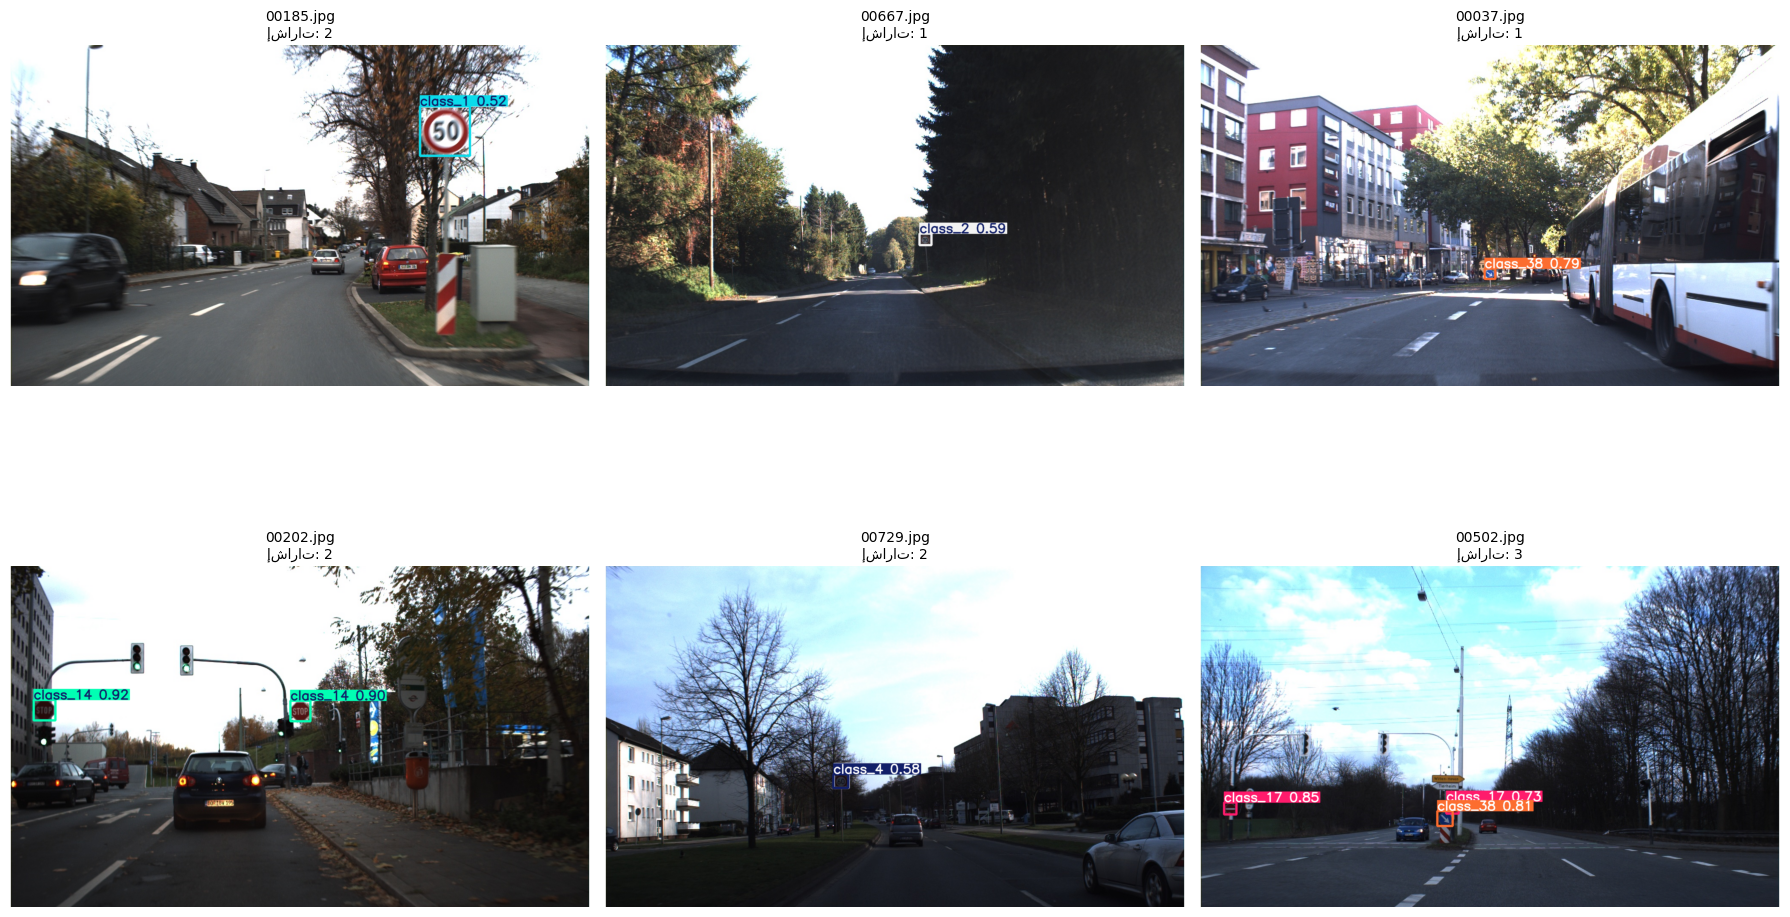

In [ ]:
# ============================================
# Results and  Visualization
# ============================================

from IPython.display import Image as IPImage


results_img = '/content/GTSDB_Training/YOLOv8_Augmented/results.png'
if os.path.exists(results_img):
    print("📈 منحنيات التدريب:")
    IPImage(results_img)


def show_predictions(num_samples=6):
    test_dir = f'{dataset_path}/images/test'
    test_images = os.listdir(test_dir)[:num_samples]

    plt.figure(figsize=(18, 12))
    for i, img_name in enumerate(test_images, 1):
        img_path = f'{test_dir}/{img_name}'
        results = best_model(img_path, conf=0.25)

        plotted = results[0].plot()
        plotted_rgb = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 3, i)
        plt.imshow(plotted_rgb)
        plt.title(f'{img_name}\nإشارات: {len(results[0].boxes)}', fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

print("\n🎯 عينات من تنبؤات النموذج:")
show_predictions()